# PlantCV Analysis of VIS (aka RGB) sideview (SV) images from experiment PC001 in the Bellwether Phenotyping Facility

Made by: Katie Murphy
Updated: August 30, 2026

## Step 1: Import Packages

First, import the necessary package. If you get an error here, make sure your kernel (upper right) is set to PlantCV, and that you have PlantCV installed. 

In [1]:
# %matplotlib widget makes the plots interactive (zoomable/pannable), which helps when you need to
# hover over the image to read off pixel coordinates (e.g. for the ROI or boundary line later on)
%matplotlib widget
# Import the main PlantCV module (all image processing functions live here)
from plantcv import plantcv as pcv
# WorkflowInputs bundles your image path(s) and output settings into one object (args), used below
from plantcv.parallel import WorkflowInputs, workflow_inputs, JupyterConfig

## Step 2: Set Up Workflow Inputs

Next, import a sample image. Your images need to be on the server. Remember, always keep your raw images separate from your newly processed images! You will need to change the path to your image, and also if you want specific output folders and directories. 

In [2]:
# this is something that we'll set interactively but that we don't want to run in parallel
# @ignore
# Input/output options
args = WorkflowInputs(
    images=["../img/VIS_SV_0_z1_h0_g370_e1500_v500_7014200_0.png"],  # path to your image
    names="image1",              # variable name to assign to the image, referenced later as args.image
    result="example_results_oneimage_file.csv",  # filename where extracted trait measurements will be saved
    outdir=".",                 # output directory for results/images ("." = current folder)
    writeimg=False,             # set to True if you want PlantCV to save output images to disk
    debug="plot"                # "plot" displays each processing step inline; use "print" to save step images to disk, or None to turn off debug images
    )


## Optional Step 2.5: Prepping for Parallelization

There are two ways to parallelize a workflow in PlantCV. The first is to make a `WorkflowConfig` object that points to an executable python script (`.py` file) and save the config to a json file. It can then be run with `plantcv-run-workflow --config config_filename.json`.
The second way is new in version 5 of PlantCV and works from jupyter using the `plantcv.parallel.JupyterConfig` class. The `JupyterConfig` object can be edited just like you would a `WorkflowConfig` object but it comes with methods to inspect your dataset before you run and to run the parallel workflow treating your jupyter session as the "head node".

Additionally there are several ways to do most subsetting when you are trying to filter images. The following three calls to `JupyterConfig` will all find the same images as shown with the output of `inspect_dataset`.

In [3]:
# @ignore
jupcon = JupyterConfig()
jupcon.verbose = False
jupcon.checkpoint = False
jupcon.input_dir = "../img/" # path relative to your notebook
jupcon.metadata_regex = {"basename": "VIS_SV.*"}
summary, full_meta = jupcon.inspect_dataset()
jupcon.cluster_config["n_workers"] = 5
summary

Run will not be verbose


,filepath,n_metadata_terms,metadata_0,metadata_1,metadata_2,metadata_3,metadata_4,metadata_5,metadata_6,metadata_7,metadata_8,metadata_9,basename,extension
status,,,,,,,,,,,,,,
Kept,3 (../img/VIS_SV_90_z1_h1_g370_e1500_v500_7748...,1 (10),1 (VIS),1 (SV),"2 (90, 0)",1 (z1),"2 (h1, h0)",1 (g370),1 (e1500),1 (v500),"3 (7748100, 7748000, 7014200)",1 (0),3 (VIS_SV_90_z1_h1_g370_e1500_v500_7748100_0.p...,1 (.png)
Removed by config.metadata_regex,1 (../img/VIS_TV_z1_h0_g370_e1800_7748200_0.png),1 (8),1 (VIS),1 (TV),1 (z1),1 (h0),1 (g370),1 (e1800),1 (7748200),1 (0),0,0,1 (VIS_TV_z1_h0_g370_e1800_7748200_0.png),1 (.png)


In [4]:
# @ignore
jupcon = JupyterConfig()
jupcon.verbose = False
jupcon.checkpoint = False
jupcon.input_dir = "../img/" # path relative to your notebook
jupcon.metadata_filters = {"metadata_0":"VIS", "metadata_1":"SV"}
jupcon.groupby = ["filepath"]
summary, full_meta = jupcon.inspect_dataset()
jupcon.cluster_config["n_workers"] = 5
summary

Run will not be verbose


,,,filepath,n_metadata_terms,metadata_2,metadata_3,metadata_4,metadata_5,metadata_6,metadata_7,metadata_8,metadata_9,basename,extension
status,metadata_0,metadata_1,,,,,,,,,,,,
Kept,VIS,SV,3 (../img/VIS_SV_90_z1_h1_g370_e1500_v500_7748...,1 (10),"2 (90, 0)",1 (z1),"2 (h1, h0)",1 (g370),1 (e1500),1 (v500),"3 (7748100, 7748000, 7014200)",1 (0),3 (VIS_SV_90_z1_h1_g370_e1500_v500_7748100_0.p...,1 (.png)
Removed by config.metadata_filters,VIS,TV,1 (../img/VIS_TV_z1_h0_g370_e1800_7748200_0.png),1 (8),1 (z1),1 (h0),1 (g370),1 (e1800),1 (7748200),1 (0),0,0,1 (VIS_TV_z1_h0_g370_e1800_7748200_0.png),1 (.png)


In [5]:
jupcon = JupyterConfig()
jupcon.verbose = False
jupcon.checkpoint = False
jupcon.input_dir = "../img/" # path relative to your notebook
jupcon.filename_metadata = ["imgtype", "camera", "angle", "zoom", "height", "gain", "exp", "view", "rep", "z"]
jupcon.metadata_filters = {"imgtype":"VIS", "camera":"SV"}
jupcon.groupby = ["filepath"]
summary, full_meta = jupcon.inspect_dataset()
jupcon.cluster_config["n_workers"] = 5
summary

Run will not be verbose


,,,filepath,n_metadata_terms,angle,height,exp,view,rep,z,zoom,gain,basename,extension
status,imgtype,camera,,,,,,,,,,,,
Incorrect metadata length,NaN,NaN,1 (../img/VIS_TV_z1_h0_g370_e1800_7748200_0.png),1 (8),0,0,0,0,0,0,0,0,1 (VIS_TV_z1_h0_g370_e1800_7748200_0.png),1 (.png)
Kept,VIS,SV,3 (../img/VIS_SV_90_z1_h1_g370_e1500_v500_7748...,1 (10),"2 (90, 0)","2 (h1, h0)",1 (e1500),1 (v500),"3 (7748100, 7748000, 7014200)",1 (0),1 (z1),1 (g370),3 (VIS_SV_90_z1_h1_g370_e1500_v500_7748100_0.p...,1 (.png)


In [6]:
# when you are ready to run in parallel save the notebook, restart the kernel (just to be safe)
# and run to this cell with `jupcon.run()` uncommmented and `args = workflow_inputs()` uncommmented in the next cell

jupcon.run()

Starting run 2026-09-21_08-41-48

Setting job_script_prologue to fetch active environment:
 ['source /home/josh/miniforge3/bin/activate', 'conda activate plantcv']
Reading image metadata...
Building job list... 
Processing images... 
/home/josh/miniforge3/envs/plantcv/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44191 instead
  warnings.warn(
Processing results... 
Converting json to csv... 


In [ ]:
args = workflow_inputs()

## Step 3: Set Debug and Display Parameters

These settings control how PlantCV shows you feedback while you build your workflow interactively, and don't affect the final trait measurements.

In [8]:
# Set debug to the global parameter, so every PlantCV function displays its output the same way
pcv.params.debug = args.debug
# Change display settings
pcv.params.dpi = 100            # resolution of displayed debug images
pcv.params.text_size = 3        # font size for annotations PlantCV draws on images
pcv.params.text_thickness = 2  # line thickness for annotations PlantCV draws on images

In [9]:
# This is a special step that we don't normally need
# in this case we have two levels of H which change
# where the pot is in the image.
import re
hline = 1950
if bool(re.search("_h0_", args.image1)):
    hline = 2150

## Step 4: Read In Your Image

Read the RGB image from the path you set above.

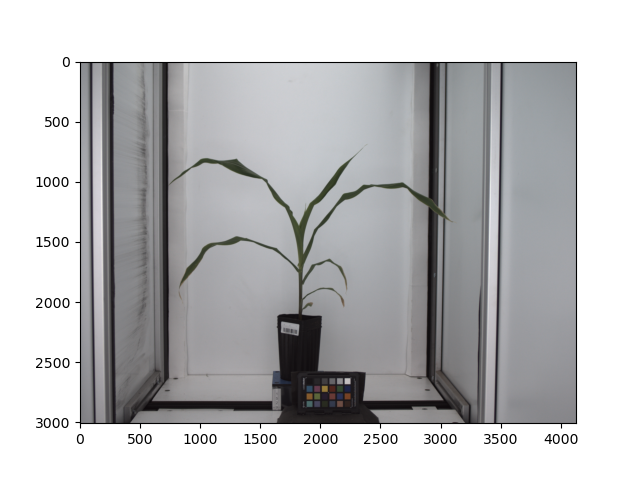

In [10]:
# Read in your image, which is based on the path you put above

# Inputs:
#   filename - Image file to be read in 
#   mode - Return mode of image; either 'native' (default), 'rgb', 'gray', or 'csv' 
img, path, filename = pcv.readimage(filename=args.image1)


## Step 5: Color-Correct the Image

Use the color card in the image to correct for lighting/camera differences, so trait values are comparable across images taken at different times.

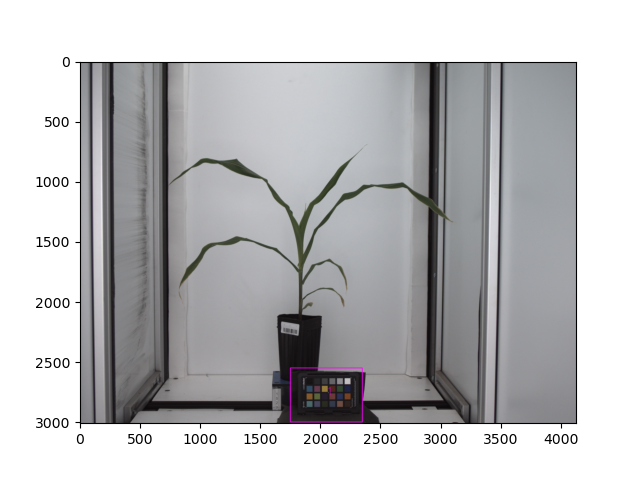

In [13]:
roi = pcv.roi.rectangle(img, 1750, 2550, 450, 600)

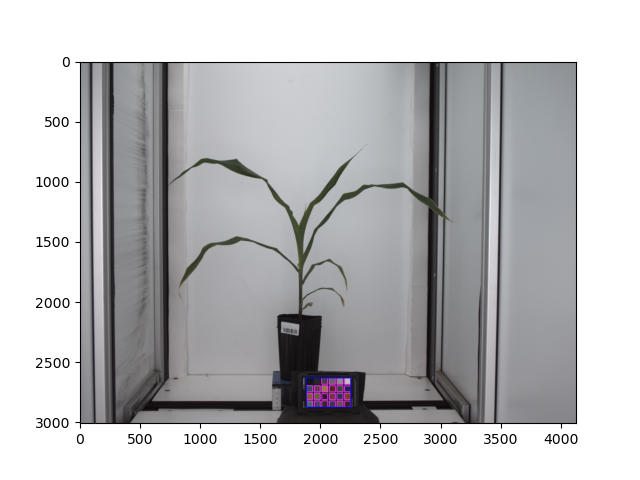

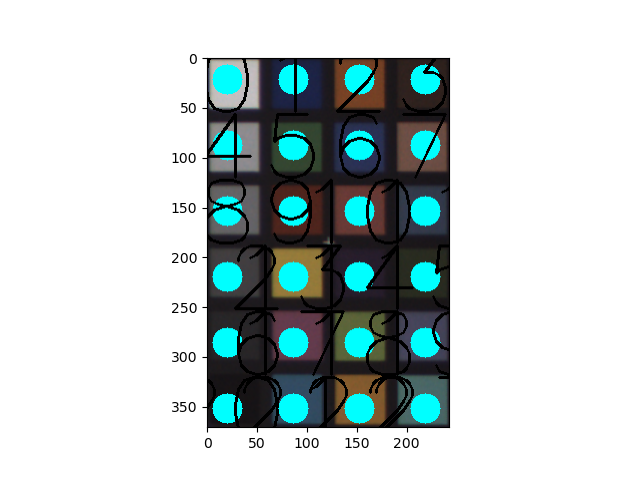

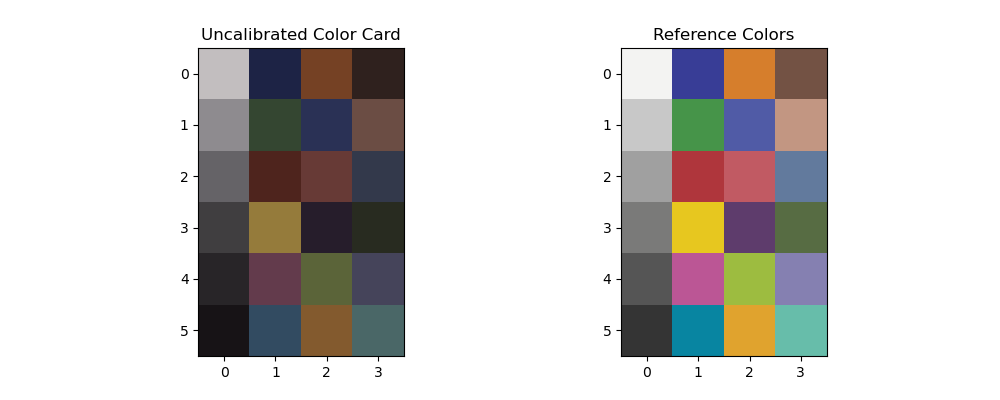

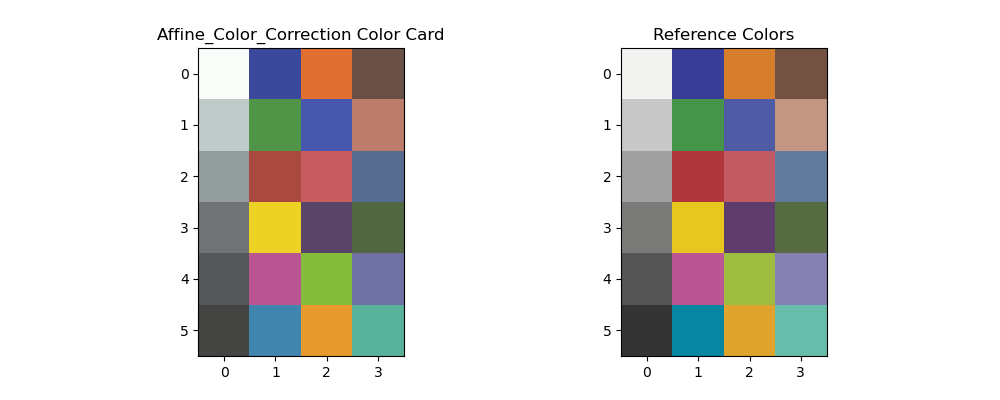

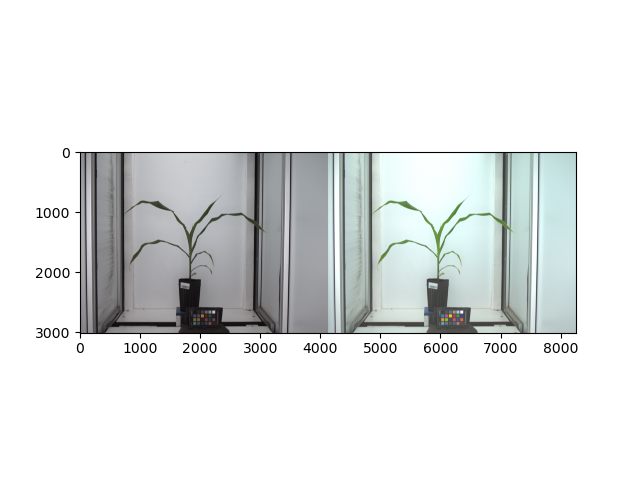

In [11]:
# Detect the color card, create a matrix of color chip values, and perform linear color correction.
img_cc = pcv.transform.auto_correct_color(rgb_img=img, radius=15, roi=roi)

## Step 6: Choose a Masking Strategy

Explore colorspaces to find a channel that best separates the plant from the background, then threshold and clean up that channel to build a binary mask.

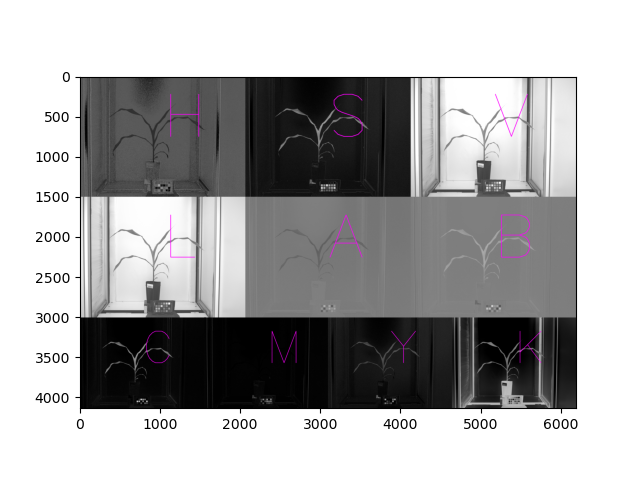

In [13]:
# Update params related to plotting so we can see better 
pcv.params.text_size=50
pcv.params.text_thickness=15


#Look at the colorspace - which of these looks the best for masking? Which channel makes the plant look most distinct?
colorspace_img = pcv.visualize.colorspaces(rgb_img=img_cc, original_img=False)

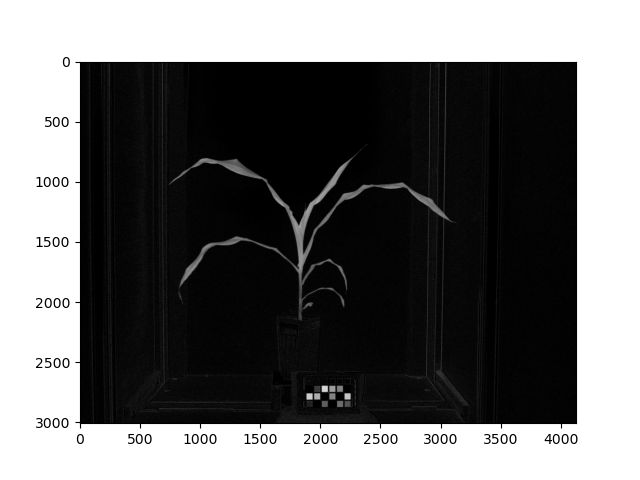

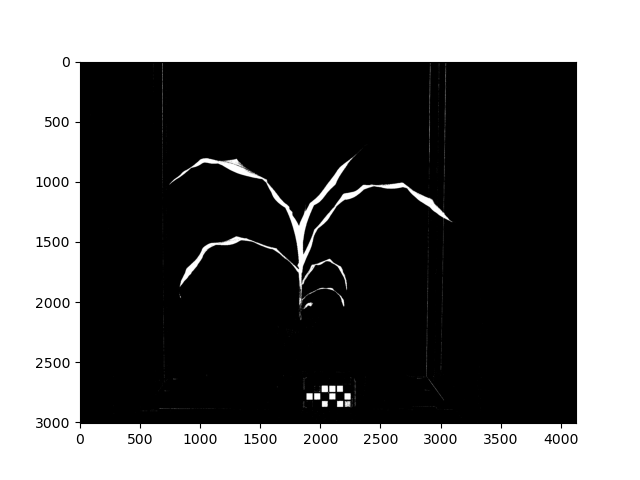

In [14]:
#mask the plant
# Convert the color-corrected image to the CMYK colorspace and keep only the cyan (c) channel,
# since that channel made the plant look most distinct from the background
gray_img = pcv.rgb2gray_cmyk(rgb_img=img_cc, channel='c')
# Turn the grayscale channel into a binary (black/white) mask: pixels lighter than 75 are kept
# as the object (the plant), since object_type='light' selects the brighter pixels
thresh_c = pcv.threshold.binary(gray_img=gray_img, threshold=75, object_type='light')

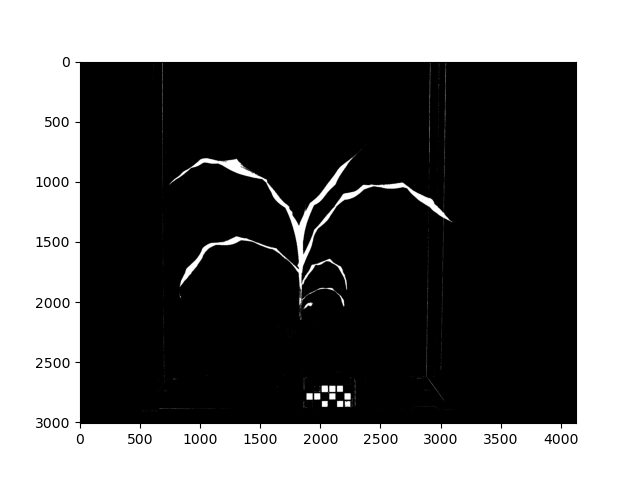

In [15]:
# Fill small holes inside the plant mask (e.g. gaps where background shows through overlapping leaves)
c_fillholes_image = pcv.fill_holes(thresh_c)

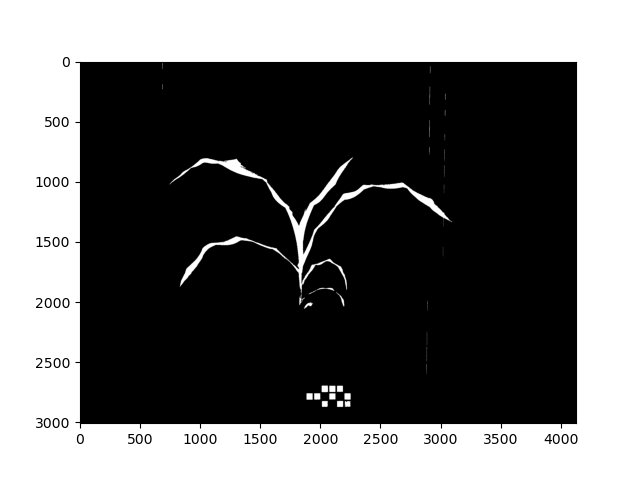

In [16]:
# Remove small noise objects from the mask that are smaller than 85 pixels (specks that aren't the plant)
c_fill_image = pcv.fill(bin_img=c_fillholes_image, size=85)

## Step 7: Define Your Region of Interest and Filter the Mask

Draw a box around where you expect your plant to be, then keep only the parts of your mask that fall inside it.

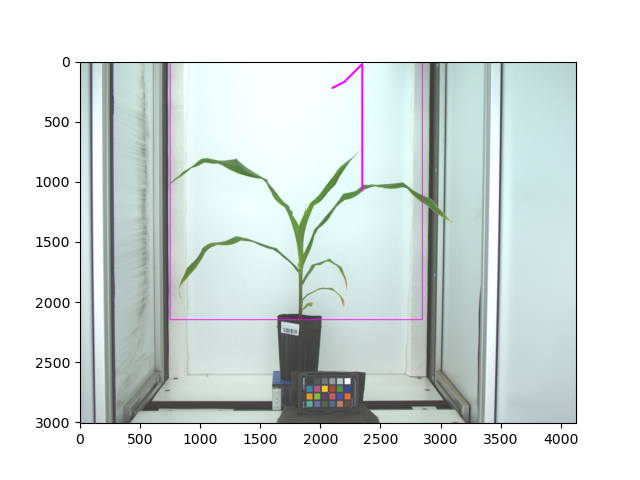

In [17]:
# Define the region of interest (ROI). This should include your plant, but not you color card or other things. 

# Inputs: 
#   img - RGB or grayscale image to plot the ROI on 
#   x - The x-coordinate of the upper left corner of the rectangle 
#   y - The y-coordinate of the upper left corner of the rectangle 
#   h - The height of the rectangle 
#   w - The width of the rectangle 

roi1 = pcv.roi.rectangle(img=img_cc, x=750, y=0, h=hline, w=2100)

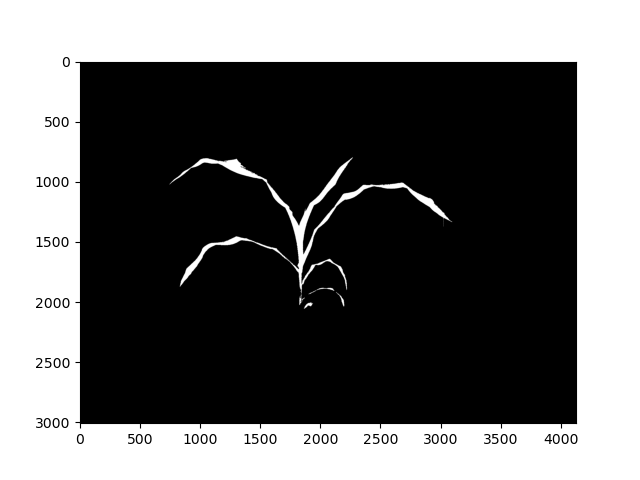

In [19]:
# Make a new filtered mask that only keeps the plant in your ROI and not objects outside of the ROI
# We have set to partial here so that if a leaf extends outside of your ROI it will still be selected. Switch to "cutto" if you have other plants that are getting selected on accident

# Inputs:
#    mask            = the clean mask you made above
#    roi            = the region of interest you specified above
#    roi_type       = 'partial' (default, for partially inside the ROI), 'cutto', or 
#                     'largest' (keep only largest contour)

kept_mask  = pcv.roi.quick_filter(mask=c_fill_image, roi=roi1, roi_type='partial')


## Step 8: Shape Analysis

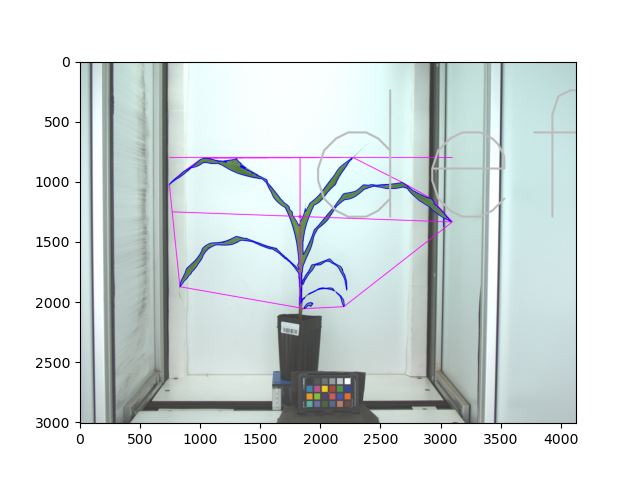

In [20]:
############### Analysis ################ 
  
# Find shape properties, data gets stored to an Outputs class automatically

# Inputs:
#   img - RGB or grayscale image data 
#   labeled_mask - the mask of each individual object, set by the create_labels function. 
#   n_labels - the number of objects, set by the create_labels function. 

analysis_image = pcv.analyze.size(img=img_cc, labeled_mask=kept_mask)


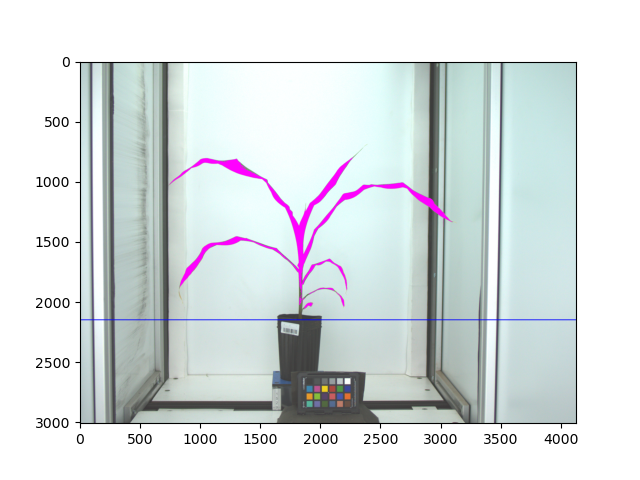

In [21]:
# Shape properties relative to user boundary line (optional). This is useful if your plant is hanging below the pot and you want height from the top of the pot.
# Set your line_position by finding the x-value at the top of the pot, hover your cursor to get that value

# Inputs:
#   img - RGB or grayscale image data 
#   obj - Single or grouped contour object 
#   mask - Binary mask of selected contours 
#   line_position - Position of boundary line (a value of 0 would draw a line 
#                   through the bottom of the image) 
#   label - Optional label parameter, modifies the variable name of observations recorded. (default `label="default"`)

boundary_image = pcv.analyze.bound_horizontal(img=img_cc,labeled_mask=kept_mask, 
                                               line_position=2150, label="default")

## Step 9: Color Analysis

In [22]:
# Determine color properties: Histograms, Color Slices and Pseudocolored Images, output color analyzed images (optional)

# Inputs:
#   rgb_img - RGB image data
#   mask - Binary mask of selected contours 
#   colorspaces - 'all' (default), 'rgb', 'lab', or 'hsv'
#                 This is the data to be printed to the SVG histogram file  
#   label - Optional label parameter, modifies the variable name of observations recorded. (default `label="default"`)

color_histogram = pcv.analyze.color(rgb_img=img_cc, labeled_mask=kept_mask, colorspaces='all', label="default")


alt.FacetChart(...)

## Step 10: Save Your Results

In [ ]:
# The save results function will take the measurements stored when running any PlantCV analysis functions, format, 
# and print an output text file for data analysis. The Outputs class stores data whenever any of the following functions
# are ran: analyze_bound_horizontal, analyze_bound_vertical, analyze_color, analyze_nir_intensity, analyze_object, 
# fluor_fvfm, report_size_marker_area, watershed. If no functions have been run, it will print an empty text file 

#This saves results for one image, and each image is saved individually if you run another image (it will overwrite the last one)
pcv.outputs.save_results(filename=args.result)


## Step 11: Build Your Batch Workflow

Congrats, you now know all the settings you like for this day of imaging! It's time to make this into a workflow so that it will analyze all your images at once and you can go have a cup of coffee. To do so, go back to the folder and open up the config_template.json file, and the config_workflow.py files, and you will edit them according to the values you changed in this file.
Alternatively, use `JupyterConfig` at the top of this notebook.